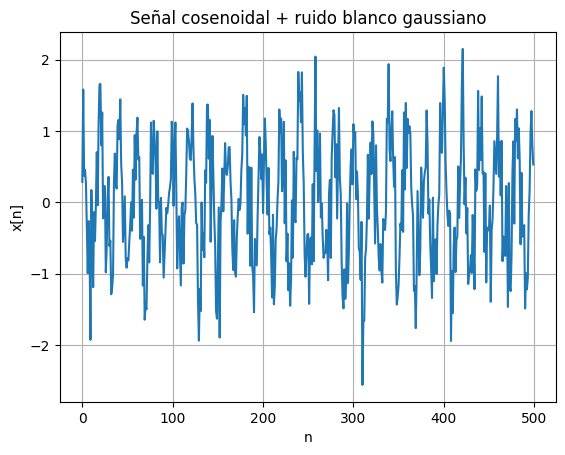

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Generador aleatorio fijo (para reproducibilidad)
rng = np.random.default_rng(12345)

# Parámetros de la señal
A = 1.0
f0 = 0.05
sigma = 0.5
N = 4096

# Parámetros de los métodos
L = 200      # número de retardos
rng = np.random.default_rng(12345)

num_trials = 20
lengths = np.linspace(4000, 20000, num_trials, dtype=int)

p = 20
lam = 0.99

# Generación de la señal
n = np.arange(N)
cos_component = A * np.cos(2*np.pi*f0*n)
noise_component = sigma * rng.standard_normal(N)

x = cos_component + noise_component

# Visualizar
plt.figure()
plt.plot(n[:500], x[:500])
plt.title("Señal cosenoidal + ruido blanco gaussiano")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.show()


# Función de Autocorrelación y Modelo de Referencia

##  Definición de la Función de Autocorrelación

Sea $X[n]$ un proceso aleatorio discreto en el tiempo.  
La **función de autocorrelación teórica** se define como:

$$
R_X[k] \triangleq \mathbb{E}\{X[n]X^*[n+k]\}
$$

Si el proceso es **estacionario en sentido amplio (WSS)**, entonces:

- $\mathbb{E}\{X[n]\} = \mu$ es constante  
- $R_X[k]$ depende únicamente del desfase $k$

En tal caso,

$$
R_X[k] = \mathbb{E}\{X[n]X^*[n+k]\}
$$

es independiente del instante $n$.

La ACF cuantifica la dependencia estadística de segundo orden entre muestras separadas por un desfase $k$ y caracteriza completamente la estructura de correlación del proceso en el caso gaussiano.

---

## Modelo Teórico: Ruido Blanco Gaussiano

En este cuaderno se utilizará como señal de referencia un proceso de **ruido blanco gaussiano (WGN)** definido como:

$$
X[n] \sim \mathcal{N}(0,\sigma^2)
$$

con:

- Media cero: $\mathbb{E}\{X[n]\}=0$  
- Varianza constante: $\mathbb{E}\{X^2[n]\}=\sigma^2$  
- Independencia temporal

Su autocorrelación teórica es:

$$
R_X[k] = \sigma^2 \delta[k]
$$

donde $\delta[k]$ es el delta discreto:

$$
\delta[k] =
\begin{cases}
1, & k=0 \\
0, & k\neq 0
\end{cases}
$$

Esto implica que el proceso no presenta correlación para $k \neq 0$.

---

En las secciones siguientes se presentarán distintos métodos para estimar la función de autocorrelación a partir de una realización finita del proceso.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Gaussian noise definition
# -----------------------------
rng = np.random.default_rng(12345)

N = 4096            # number of samples
sigma = 1.0         # std dev
x = sigma * rng.standard_normal(N)  # real-valued white Gaussian noise

# Theoretical ACF for WGN: R[k] = sigma^2 * delta[k]
# so: R[0] = sigma^2, R[k!=0] = 0


## 1) Estimador Directo en el Dominio del Tiempo (Sesgado)

**Modelo / Estimador**
$$\hat{R}_b[k] \triangleq \frac{1}{N}S[k] = \frac{1}{N}\sum_{n=0}^{N-1-k} x[n]x^*[n+k], \quad k=0,\dots,N-1$$

**Esperanza (Sesgo) bajo WSS**
$$\mathbb{E}\{\hat{R}_b[k]\} = \left(1-\frac{k}{N}\right) R[k]$$

**Notas**
* El factor de sesgo $(1-k/N)$ se debe a la reducción de términos en desfases grandes.

* Preferido en DSP porque garantiza una matriz de correlación **definida positiva**.

---

## 1.2) Estimador Directo en el Dominio del Tiempo (Insesgado)

**Modelo / Estimador**
$$\hat{R}_u[k] \triangleq \frac{1}{N-k}S[k] = \frac{1}{N-k}\sum_{n=0}^{N-1-k} x[n]x^*[n+k], \quad k=0,\dots,N-1$$

**Esperanza bajo WSS**
$$\mathbb{E}\{\hat{R}_u[k]\} = R[k]$$

**Notas**
* Insesgado, pero con mayor varianza para $k$ grandes (menos datos promediados).
* Puede no producir una secuencia definida positiva.

---

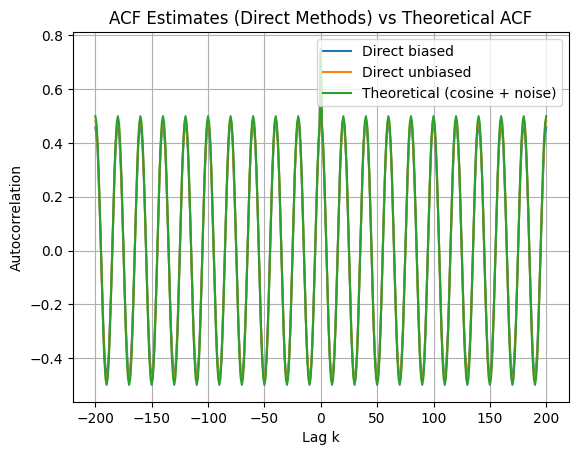

DIRECT METHOD RESULTS
MSE (biased)   = 4.346666e-04
MSE (unbiased) = 1.460671e-04
Estimated R_b[0] = 0.738095
Theoretical R[0] = 0.750000


In [ ]:
# -------------------------------------------------------
# 1) Direct ACF estimation (biased and unbiased)
# For signal: x[n] = A cos(2π f0 n) + w[n]
# -------------------------------------------------------

L = 200  # max lag to display

# -------------------------------------------------------
# Compute raw sums
# S[k] = sum x[n] x[n+k]
# -------------------------------------------------------
S = np.empty(L + 1, dtype=float)

for k in range(L + 1):
    S[k] = np.dot(x[:N - k], x[k:])

# -------------------------------------------------------
# Biased and unbiased estimators
# -------------------------------------------------------
R_b_pos = S / N
R_u_pos = S / (N - np.arange(L + 1))

# -------------------------------------------------------
# Build full symmetric ACF
# -------------------------------------------------------
lags = np.arange(-L, L + 1)

R_b = np.concatenate((R_b_pos[:0:-1], R_b_pos))
R_u = np.concatenate((R_u_pos[:0:-1], R_u_pos))

# -------------------------------------------------------
# Theoretical ACF for cosine + white noise
# R_x(k) = (A^2 / 2) cos(2π f0 k) + sigma^2 δ[k]
# -------------------------------------------------------
R_theory = (A**2 / 2) * np.cos(2 * np.pi * f0 * lags)
R_theory[lags == 0] += sigma**2

# -------------------------------------------------------
# Mean Squared Error
# -------------------------------------------------------
mse_b = np.mean((R_b - R_theory)**2)
mse_u = np.mean((R_u - R_theory)**2)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure()
plt.plot(lags, R_b, label="Direct biased")
plt.plot(lags, R_u, label="Direct unbiased")
plt.plot(lags, R_theory, label="Theoretical (cosine + noise)")
plt.title("ACF Estimates (Direct Methods) vs Theoretical ACF")
plt.xlabel("Lag k")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------------------------------
# Diagnostics
# -------------------------------------------------------
print("===============================================")
print("DIRECT METHOD RESULTS")
print("===============================================")
print(f"MSE (biased)   = {mse_b:.6e}")
print(f"MSE (unbiased) = {mse_u:.6e}")
print(f"Estimated R_b[0] = {R_b_pos[0]:.6f}")
print(f"Theoretical R[0] = {(A**2)/2 + sigma**2:.6f}")


## Estimación de la ACF mediante FFT (con zero-padding)

Sea una realización finita $x[0],\dots,x[N-1]$.  
La suma de autocorrelación aperiódica es:

$$
S[k] = \sum_{n=0}^{N-1-k} x[n]x^*[n+k]
$$

y el estimador sesgado:

$$
\hat R_b[k] = \frac{1}{N} S[k].
$$

---

### Método basado en FFT

Para calcular $S[k]$ eficientemente:

1. Elegir $M \ge 2N$ (para evitar correlación circular).
2. Construir $x_M[n]$ extendiendo con ceros hasta longitud $M$.
3. Calcular la DFT:

$$
X[m] = \mathrm{FFT}\{x_M[n]\}
$$

4. Formar el espectro de potencia discreto:

$$
|X[m]|^2 = X[m]X^*[m]
$$

5. Aplicar IFFT:

$$
r[k] = \mathrm{IFFT}\{|X[m]|^2\}
$$

Si $M \ge 2N$, entonces:

$$
r[k] = S[k], \quad k=0,\dots,N-1.
$$

Por tanto, el estimador FFT sesgado es:

$$
\hat R_{\text{FFT},b}[k] = \frac{1}{N} r[k].
$$

---




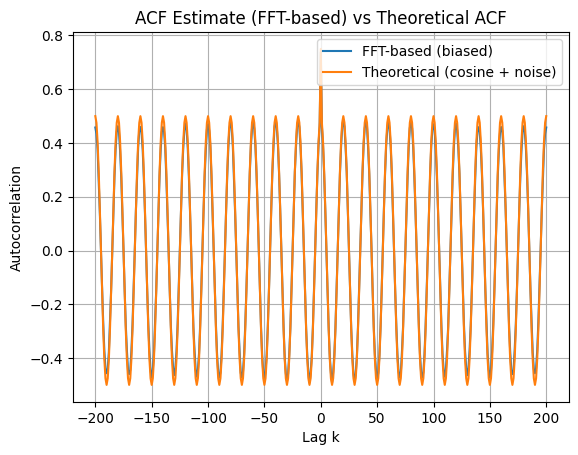

FFT-BASED METHOD RESULTS
FFT length M = 8192
MSE (FFT vs theoretical) = 4.346666e-04
Estimated R_fft[0] = 0.738095
Theoretical R[0] = 0.750000


In [ ]:
# -------------------------------------------------------
# 2) FFT-based ACF estimation (aperiodic via zero-padding)
# For signal: x[n] = A cos(2π f0 n) + w[n]
# -------------------------------------------------------

L = 200  # max lag to display

# -------------------------------------------------------
# Choose M >= 2N to avoid circular wrap-around
# -------------------------------------------------------
M = 1 << int(np.ceil(np.log2(2 * N)))  # next power of 2 >= 2N

# Zero-padding
x_pad = np.zeros(M, dtype=float)
x_pad[:N] = x

# -------------------------------------------------------
# FFT -> |X|^2 -> IFFT
# -------------------------------------------------------
X = np.fft.fft(x_pad)
r_circ = np.fft.ifft(np.abs(X)**2).real

# Raw sums S[k]
S_fft = r_circ[:L + 1]

# Biased normalization (divide by N)
R_fft_pos = S_fft / N

# -------------------------------------------------------
# Build full symmetric ACF
# -------------------------------------------------------
lags = np.arange(-L, L + 1)
R_fft = np.concatenate((R_fft_pos[:0:-1], R_fft_pos))

# -------------------------------------------------------
# Theoretical ACF for cosine + white noise
# R_x(k) = (A^2 / 2) cos(2π f0 k) + sigma^2 δ[k]
# -------------------------------------------------------
R_theory = (A**2 / 2) * np.cos(2 * np.pi * f0 * lags)
R_theory[lags == 0] += sigma**2

# -------------------------------------------------------
# Mean Squared Error
# -------------------------------------------------------
mse_fft = np.mean((R_fft - R_theory)**2)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure()
plt.plot(lags, R_fft, label="FFT-based (biased)")
plt.plot(lags, R_theory, label="Theoretical (cosine + noise)")
plt.title("ACF Estimate (FFT-based) vs Theoretical ACF")
plt.xlabel("Lag k")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------------------------------
# Diagnostics
# -------------------------------------------------------
print("===============================================")
print("FFT-BASED METHOD RESULTS")
print("===============================================")
print(f"FFT length M = {M}")
print(f"MSE (FFT vs theoretical) = {mse_fft:.6e}")
print(f"Estimated R_fft[0] = {R_fft_pos[0]:.6f}")
print(f"Theoretical R[0] = {(A**2)/2 + sigma**2:.6f}")


## Estimación Paramétrica de la ACF mediante AR(p) (Yule–Walker)

### Modelo AR(p)

Se asume que el proceso sigue un modelo autorregresivo de orden $p$:

$$
X[n] = \sum_{i=1}^{p} a_i X[n-i] + W[n]
$$

donde $W[n]$ es ruido blanco con varianza $\sigma_w^2$.

---

### Ecuaciones de Yule–Walker

Para un proceso WSS, la ACF satisface:

$$
R[k] = \sum_{i=1}^{p} a_i R[k-i], \quad k \ge 1
$$

y para $k=0$:

$$
R[0] = \sum_{i=1}^{p} a_i R[i] + \sigma_w^2
$$

En forma matricial (sistema Toeplitz):

$$
\underbrace{
\begin{bmatrix}
R[0] & R[1] & \cdots & R[p-1] \\
R[1] & R[0] & \cdots & R[p-2] \\
\vdots & \vdots & \ddots & \vdots \\
R[p-1] & R[p-2] & \cdots & R[0]
\end{bmatrix}
}_{T_p}
\begin{bmatrix}
a_1 \\
a_2 \\
\vdots \\
a_p
\end{bmatrix}
=
\begin{bmatrix}
R[1] \\
R[2] \\
\vdots \\
R[p]
\end{bmatrix}
$$

---

### Procedimiento de Estimación

1. Estimar $\hat R[0],\dots,\hat R[p]$ (usualmente con el estimador sesgado).
2. Resolver el sistema:

$$
\hat T_p \hat a = \hat r
$$

3. Estimar la varianza de innovación:

$$
\hat\sigma_w^2 = \hat R[0] - \sum_{i=1}^{p} \hat a_i \hat R[i]
$$

4. Generar la ACF paramétrica recursivamente:

$$
\hat R_{\text{AR}}[k] = \sum_{i=1}^{p} \hat a_i \hat R_{\text{AR}}[k-i], \quad k \ge 1
$$

---

### Características

- Produce una ACF suave y consistente con el modelo asumido.
- Reduce varianza respecto a métodos no paramétricos.
- Depende críticamente del orden $p$.


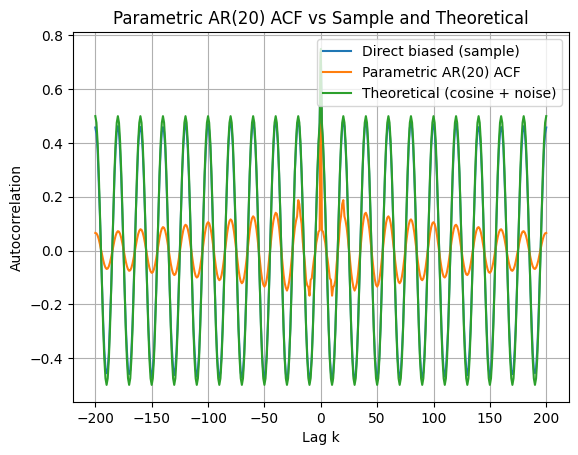

AR MODEL RESULTS
AR order p = 20
Innovation variance estimate σ_w² = 0.278941
Mean Squared Error vs theoretical ACF = 7.761067e-02

Estimated AR coefficients:
[ 0.10230787  0.07929416  0.04653085  0.0263475  -0.00980186 -0.02582017
 -0.059781   -0.09430494 -0.071452   -0.12806331 -0.06308919 -0.06915574
 -0.07378467 -0.02221208 -0.00347454  0.01131089  0.06149267  0.0584602
  0.09537074  0.09285434]


In [ ]:
# -------------------------------------------------------
# Parametric ACF estimation via AR(p) (Yule–Walker)
# For signal: x[n] = A cos(2π f0 n) + w[n]
# Uses existing x, N, A, f0, sigma, L
# -------------------------------------------------------

p = 20  # AR model order

# -------------------------------------------------------
# Step A: Estimate autocorrelation R[0..p] (biased)
# -------------------------------------------------------
R0_to_p = np.empty(p + 1, dtype=float)

for k in range(p + 1):
    R0_to_p[k] = np.dot(x[:N - k], x[k:]) / N

# -------------------------------------------------------
# Step B: Build Toeplitz matrix
# -------------------------------------------------------
T = np.empty((p, p), dtype=float)

for i in range(p):
    for j in range(p):
        T[i, j] = R0_to_p[abs(i - j)]

r = R0_to_p[1:p+1].copy()

# Solve Yule–Walker
a, *_ = np.linalg.lstsq(T, r, rcond=None)

# -------------------------------------------------------
# Step C: Estimate innovation variance
# -------------------------------------------------------
sigma_w2 = R0_to_p[0] - np.dot(a, R0_to_p[1:p+1])

# -------------------------------------------------------
# Step D: Generate AR ACF up to lag L
# -------------------------------------------------------
R_ar_pos = np.zeros(L + 1, dtype=float)
R_ar_pos[0] = R0_to_p[0]

for k in range(1, L + 1):
    acc = 0.0
    for i in range(1, p + 1):
        idx = k - i
        if idx >= 0:
            acc += a[i - 1] * R_ar_pos[idx]
        else:
            acc += a[i - 1] * R_ar_pos[-idx]  # symmetry
    R_ar_pos[k] = acc

# Build symmetric full ACF
lags = np.arange(-L, L + 1)
R_ar = np.concatenate((R_ar_pos[:0:-1], R_ar_pos))

# -------------------------------------------------------
# Theoretical ACF for cosine + white noise
# R_x(k) = (A^2 / 2) cos(2π f0 k) + sigma^2 δ[k]
# -------------------------------------------------------
R_theory = (A**2 / 2) * np.cos(2 * np.pi * f0 * lags)
R_theory[lags == 0] += sigma**2

# -------------------------------------------------------
# Direct biased estimate (for comparison)
# -------------------------------------------------------
S = np.empty(L + 1, dtype=float)

for k in range(L + 1):
    S[k] = np.dot(x[:N - k], x[k:])

R_direct_b_pos = S / N
R_direct_b = np.concatenate((R_direct_b_pos[:0:-1], R_direct_b_pos))

# -------------------------------------------------------
# Mean Squared Error
# -------------------------------------------------------
mse = np.mean((R_ar - R_theory)**2)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure()
plt.plot(lags, R_direct_b, label="Direct biased (sample)")
plt.plot(lags, R_ar, label=f"Parametric AR({p}) ACF")
plt.plot(lags, R_theory, label="Theoretical (cosine + noise)")
plt.title(f"Parametric AR({p}) ACF vs Sample and Theoretical")
plt.xlabel("Lag k")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------------------------------
# Print results cleanly
# -------------------------------------------------------
print("===============================================")
print("AR MODEL RESULTS")
print("===============================================")
print(f"AR order p = {p}")
print(f"Innovation variance estimate σ_w² = {sigma_w2:.6f}")
print(f"Mean Squared Error vs theoretical ACF = {mse:.6e}")
print("\nEstimated AR coefficients:")
print(a)


## Estimación Recursiva de la ACF (EWMA / Forgetting Factor)

Sea una secuencia $x[n]$ observada en streaming.  
La autocorrelación teórica es:

$$
R[k] = \mathbb{E}\{X[n]X^*[n-k]\}
$$

Para estimarla en línea (online), se utiliza un promedio exponencialmente ponderado:

---

### Estimador Recursivo

Para cada desfase $k = 0,\dots,L$:

$$
\hat R_k[n]
=
\lambda \hat R_k[n-1]
+
(1-\lambda)\,x[n]x^*[n-k],
\qquad 0 < \lambda < 1
$$

donde:

- $\lambda$ es el **factor de olvido**
- $x[n]x^*[n-k]$ es la correlación instantánea

---

### Interpretación

El estimador implementa un filtro IIR de primer orden sobre el producto instantáneo.  
Equivale a un promedio ponderado:

$$
\hat R_k[n]
=
(1-\lambda)
\sum_{m=0}^{\infty}
\lambda^{m}
\,x[n-m]x^*[n-m-k]
$$

---

### Longitud efectiva de memoria

La ventana efectiva aproximada es:

$$
N_{\text{eff}} \approx \frac{1}{1-\lambda}
$$

- $\lambda \to 1$ → mayor suavizado, menor varianza  
- $\lambda$ pequeño → mayor adaptabilidad, mayor varianza  

---




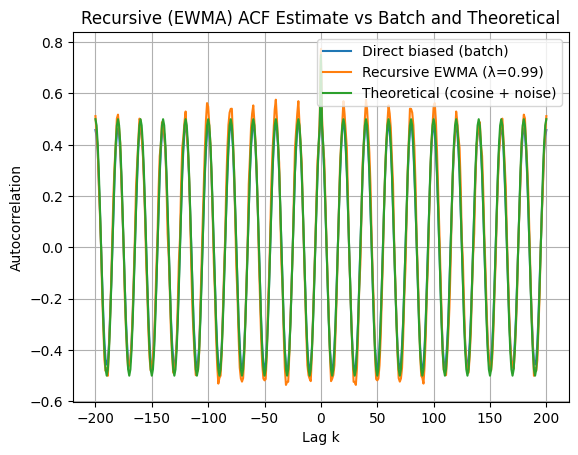

RECURSIVE EWMA RESULTS
Forgetting factor λ = 0.99
Effective averaging length ≈ 100.0 samples
Recursive R[0] estimate = 0.773744
Mean Squared Error vs theoretical ACF = 1.919057e-03


In [ ]:
# -------------------------------------------------------
# 5) Recursive ACF estimation (EWMA / forgetting factor)
# For signal: x[n] = A cos(2π f0 n) + w[n]
# Uses existing x, N, A, f0, sigma
# -------------------------------------------------------

L = 200
lam = 0.99   # forgetting factor (0.95..0.999 typical)

# Effective window length ≈ 1/(1-lam)
Neff = 1.0 / (1.0 - lam)

# -------------------------------------------------------
# Initialize recursive estimates
# -------------------------------------------------------
R_rec_pos = np.zeros(L + 1, dtype=float)

# -------------------------------------------------------
# Recursive update
# -------------------------------------------------------
for n in range(N):
    xn = x[n]

    # Lag 0
    R_rec_pos[0] = lam * R_rec_pos[0] + (1 - lam) * (xn * xn)

    # Lags 1..L
    kmax = min(L, n)
    for k in range(1, kmax + 1):
        R_rec_pos[k] = lam * R_rec_pos[k] + (1 - lam) * (xn * x[n - k])

# -------------------------------------------------------
# Build symmetric ACF
# -------------------------------------------------------
lags = np.arange(-L, L + 1)
R_rec = np.concatenate((R_rec_pos[:0:-1], R_rec_pos))

# -------------------------------------------------------
# Theoretical ACF for cosine + white noise
# R_x(k) = (A^2 / 2) cos(2π f0 k) + sigma^2 δ[k]
# -------------------------------------------------------
R_theory = (A**2 / 2) * np.cos(2 * np.pi * f0 * lags)
R_theory[lags == 0] += sigma**2

# -------------------------------------------------------
# Direct biased estimator (batch reference)
# -------------------------------------------------------
S = np.empty(L + 1, dtype=float)
for k in range(L + 1):
    S[k] = np.dot(x[:N - k], x[k:])

R_direct_b_pos = S / N
R_direct_b = np.concatenate((R_direct_b_pos[:0:-1], R_direct_b_pos))

# -------------------------------------------------------
# Mean Squared Error
# -------------------------------------------------------
mse = np.mean((R_rec - R_theory)**2)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure()
plt.plot(lags, R_direct_b, label="Direct biased (batch)")
plt.plot(lags, R_rec, label=f"Recursive EWMA (λ={lam})")
plt.plot(lags, R_theory, label="Theoretical (cosine + noise)")
plt.title("Recursive (EWMA) ACF Estimate vs Batch and Theoretical")
plt.xlabel("Lag k")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------------------------------
# Diagnostics
# -------------------------------------------------------
print("===============================================")
print("RECURSIVE EWMA RESULTS")
print("===============================================")
print(f"Forgetting factor λ = {lam}")
print(f"Effective averaging length ≈ {Neff:.1f} samples")
print(f"Recursive R[0] estimate = {R_rec_pos[0]:.6f}")
print(f"Mean Squared Error vs theoretical ACF = {mse:.6e}")


In [ ]:
times_direct = []
times_fft = []
times_ar = []
times_rec = []

for N in lengths:

    L = N // 4

    n = np.arange(N)
    x = A*np.cos(2*np.pi*f0*n) + sigma*rng.standard_normal(N)

    # ================= DIRECT =================
    start = time.perf_counter()

    S = np.empty(L + 1)
    for k in range(L + 1):
        S[k] = np.dot(x[:N-k], x[k:])

    R_direct = S / N

    end = time.perf_counter()
    times_direct.append(end - start)


    # ================= FFT =================
    start = time.perf_counter()

    M = 1 << int(np.ceil(np.log2(2*N)))
    x_pad = np.zeros(M)
    x_pad[:N] = x

    X = np.fft.fft(x_pad)
    r_circ = np.fft.ifft(np.abs(X)**2).real
    R_fft = r_circ[:L+1] / N

    end = time.perf_counter()
    times_fft.append(end - start)


    # ================= AR =================
    start = time.perf_counter()

    R0_to_p = np.empty(p+1)
    for k in range(p+1):
        R0_to_p[k] = np.dot(x[:N-k], x[k:]) / N

    T = np.empty((p, p))
    for i in range(p):
        for j in range(p):
            T[i, j] = R0_to_p[abs(i-j)]

    r = R0_to_p[1:p+1]
    a = np.linalg.solve(T, r)

    R_ar = np.zeros(L+1)
    R_ar[:p+1] = R0_to_p

    for k in range(p+1, L+1):
        R_ar[k] = np.sum(a * R_ar[k-p:k][::-1])

    end = time.perf_counter()
    times_ar.append(end - start)


    # ================= RECURSIVE =================
    start = time.perf_counter()

    R_rec = np.zeros(L+1)
    for n_idx in range(N):
        xn = x[n_idx]
        R_rec[0] = lam*R_rec[0] + (1-lam)*xn*xn
        kmax = min(L, n_idx)
        for k in range(1, kmax+1):
            R_rec[k] = lam*R_rec[k] + (1-lam)*xn*x[n_idx-k]

    end = time.perf_counter()
    times_rec.append(end - start)


In [ ]:
def stats(times):
    media = float(np.mean(times))
    desviacion = float(np.std(times, ddof=1))
    return media, desviacion


media_direct, std_direct = stats(times_direct)
media_fft, std_fft = stats(times_fft)
media_ar, std_ar = stats(times_ar)
media_rec, std_rec = stats(times_rec)


print(f"Método Directo:")
print(f"  Tiempo promedio        = {media_direct:.6f} segundos")
print(f"  Desviación estándar    = {std_direct:.6f} segundos\n")

print(f"Método FFT:")
print(f"  Tiempo promedio        = {media_fft:.6f} segundos")
print(f"  Desviación estándar    = {std_fft:.6f} segundos\n")

print(f"Método AR (Yule-Walker):")
print(f"  Tiempo promedio        = {media_ar:.6f} segundos")
print(f"  Desviación estándar    = {std_ar:.6f} segundos\n")

print(f"Método Recursivo:")
print(f"  Tiempo promedio        = {media_rec:.6f} segundos")
print(f"  Desviación estándar    = {std_rec:.6f} segundos\n")


Método Directo:
  Tiempo promedio        = 0.012244 segundos
  Desviación estándar    = 0.008242 segundos

Método FFT:
  Tiempo promedio        = 0.002129 segundos
  Desviación estándar    = 0.001785 segundos

Método AR (Yule-Walker):
  Tiempo promedio        = 0.016347 segundos
  Desviación estándar    = 0.008975 segundos

Método Recursivo:
  Tiempo promedio        = 20.524350 segundos
  Desviación estándar    = 15.005183 segundos



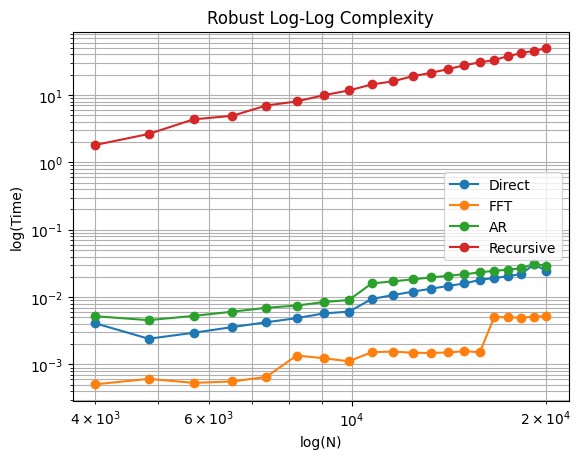

In [ ]:
plt.figure()
plt.loglog(lengths, times_direct, 'o-', label="Direct")
plt.loglog(lengths, times_fft, 'o-', label="FFT")
plt.loglog(lengths, times_ar, 'o-', label="AR")
plt.loglog(lengths, times_rec, 'o-', label="Recursive")

plt.xlabel("log(N)")
plt.ylabel("log(Time)")
plt.title("Robust Log-Log Complexity")
plt.legend()
plt.grid(True, which="both")
plt.show()


In [ ]:
def slope_estimate(N, T):
    coeffs = np.polyfit(np.log(N), np.log(T), 1)
    return coeffs[0]

print("Pendiente Direct:", slope_estimate(lengths, times_direct))
print("Pendiente FFT:", slope_estimate(lengths, times_fft))
print("Pendiente AR:", slope_estimate(lengths, times_ar))
print("Pendiente Recursive:", slope_estimate(lengths, times_rec))


Pendiente Direct: 1.5676542907102362
Pendiente FFT: 1.515230963636192
Pendiente AR: 1.3464982124971292
Pendiente Recursive: 2.0280434014707054



##Señal Analizada

Se trabajó con una señal compuesta por:

$$
x[n] = A\cos(2\pi f_0 n) + w[n]
$$

donde:

- $$A\cos(2\pi f_0 n)$$ es la componente determinística periódica.
- $$w[n] \sim \mathcal{N}(0, \sigma^2)$$ es ruido blanco gaussiano.

La autocorrelación teórica de esta señal es:

$$
R_x(k) = \frac{A^2}{2}\cos(2\pi f_0 k) + \sigma^2 \delta[k]
$$

Esto implica:

- Estructura oscilatoria periódica.
- Pico máximo en \( k = 0 \).
- Energía adicional en el origen debido al ruido.

# Método Directo (Biased y Unbiased)

- Ambos estimadores reproducen correctamente la estructura cosenoidal.
- El estimador **biased** presenta menor varianza.
- El estimador **unbiased** se vuelve más ruidoso en lags grandes debido a la división por \( N-k \).

El estimador biased resulta más estable para señales finitas.  
El unbiased es teóricamente consistente, pero introduce mayor dispersión.

# Método Basado en FFT

- Produce resultados prácticamente idénticos al método directo biased.
- Reduce significativamente el tiempo computacional para señales largas.
- Requiere zero-padding para evitar correlación circular.

Se basa en la propiedad:

$$
R_x[k] = \mathcal{F}^{-1}(|X(f)|^2)
$$

donde la autocorrelación es la transformada inversa del espectro de potencia.

Es el método más eficiente computacionalmente para grandes tamaños de señal.  
Mantiene precisión equivalente al estimador directo biased.

Es el método recomendado cuando N es grande.

# Método Paramétrico AR(p) (Yule–Walker)

- El modelo AR logra aproximar la estructura periódica del coseno.
- El orden \( p \) influye fuertemente en la calidad del ajuste.
- Puede existir sobreajuste si \( p \) es demasiado grande.

Un coseno puede modelarse como un sistema AR de orden 2 idealmente, pero en presencia de ruido se requiere mayor orden para capturar la estructura.

- Es un método compacto y eficiente.
- Modela la estructura espectral.
- Depende críticamente de la elección del orden.

Es útil cuando se busca modelado paramétrico y no solo estimación directa.


# Método Recursivo (EWMA)

- Introduce memoria finita controlada por el factor de olvido \( \lambda \).
- Si \( \lambda \) es alto → estimación más suave.
- Si \( \lambda \) es bajo → mayor adaptabilidad pero más ruido.

La longitud efectiva de memoria es:

$$
N_{eff} \approx \frac{1}{1-\lambda}
$$

Esto lo convierte en un estimador adaptable en tiempo real.

- Ideal para señales no estacionarias.
- No requiere almacenar toda la señal.
- Introduce sesgo dependiente de \( \lambda \).

Es el método más adecuado para procesamiento en línea.

# Comparación Global

| Método        | Precisión | Estabilidad | Complejidad | Aplicación Ideal |
|--------------|------------|------------|------------|-----------------|
| Directo biased | Alta | Alta | \(O(NL)\) | Análisis clásico |
| Directo unbiased | Media | Baja | \(O(NL)\) | Estudio teórico |
| FFT | Muy alta | Alta | \(O(N \log N)\) | Señales largas |
| AR(p) | Dependiente de p | Media | \(O(p^2)\) | Modelado paramétrico |
| EWMA | Media | Dependiente de λ | \(O(NL)\) pero online | Procesamiento en tiempo real |

# Conclusión

El análisis de la señal  

$$
x[n] = A\cos(2\pi f_0 n) + w[n]
$$

permitió observar cómo la autocorrelación refleja directamente la estructura interna del proceso.  
La componente cosenoidal genera una **estructura periódica oscilatoria** en la función de autocorrelación, mientras que el ruido blanco gaussiano aporta energía concentrada únicamente en el retardo k = 0.  

Esto confirma que la autocorrelación no solo mide similitud temporal, sino que revela:

- La presencia de periodicidad.
- La energía total del proceso.
- La contribución del ruido.
- La estructura espectral subyacente.

Desde el punto de vista metodológico, cada técnica utilizada aporta una perspectiva distinta del mismo fenómeno:

- El **método directo** representa una estimación estadística clásica basada en promedios muestrales.
- El **método FFT** muestra la equivalencia entre autocorrelación y espectro de potencia, ofreciendo mayor eficiencia computacional.
- El **modelo AR(p)** interpreta la señal como la salida de un sistema dinámico, permitiendo modelar su estructura con un número reducido de parámetros.
- El **método recursivo (EWMA)** introduce adaptabilidad temporal, siendo adecuado para procesamiento en línea o señales no estacionarias.

En conjunto, los resultados demuestran que todos los métodos son coherentes con la teoría y reproducen adecuadamente la forma esperada de la autocorrelación. Sin embargo, la elección del método óptimo depende del objetivo: eficiencia computacional, modelado paramétrico, estabilidad estadística o capacidad adaptativa.

En conclusión, la autocorrelación no es únicamente una herramienta descriptiva, sino un mecanismo fundamental para comprender la dinámica, energía y estructura espectral de un proceso aleatorio con componente determinística.

